# Garbage Classification & Bin Navigator
## Problem Definition

Improper waste disposal is a growing environmental problem. 
This project builds a deep learning model that:
1. **Classifies** a garbage image into one of 6 categories
2. **Recommends** the correct disposal bin for that category

### Classes
- Cardboard, Glass, Metal, Paper, Plastic, Trash

### Dataset
- Source: Kaggle Garbage Classification Dataset
- Size: ~2,500 images across 6 classes
- Format: Pre-organized folders (one per class)

### Goals
- Build a baseline CNN from scratch
- Improve with data augmentation and regularization
- Apply ResNet18 transfer learning for best accuracy
- Deploy a bin navigation function on top of the classifier

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

# reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.8.0+cpu
Device: cpu


In [3]:
DATA_DIR = os.path.join("..", "data", "garbage_classification")
CLASSES = sorted(os.listdir(DATA_DIR))
print("Classes found:", CLASSES)
print("Number of classes:", len(CLASSES))

Classes found: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of classes: 6


## Section 2: Exploratory Data Analysis (EDA)
Understanding the dataset before building any model.

In [4]:
# count images per class
class_counts = {}
for cls in CLASSES:
    cls_path = os.path.join(DATA_DIR, cls)
    class_counts[cls] = len(os.listdir(cls_path))

total = sum(class_counts.values())
print("Image counts per class:")
for cls, count in class_counts.items():
    print(f"  {cls:12s}: {count} images ({count/total*100:.1f}%)")
print(f"\n  Total images: {total}")

Image counts per class:
  cardboard   : 403 images (15.9%)
  glass       : 501 images (19.8%)
  metal       : 410 images (16.2%)
  paper       : 594 images (23.5%)
  plastic     : 482 images (19.1%)
  trash       : 137 images (5.4%)

  Total images: 2527


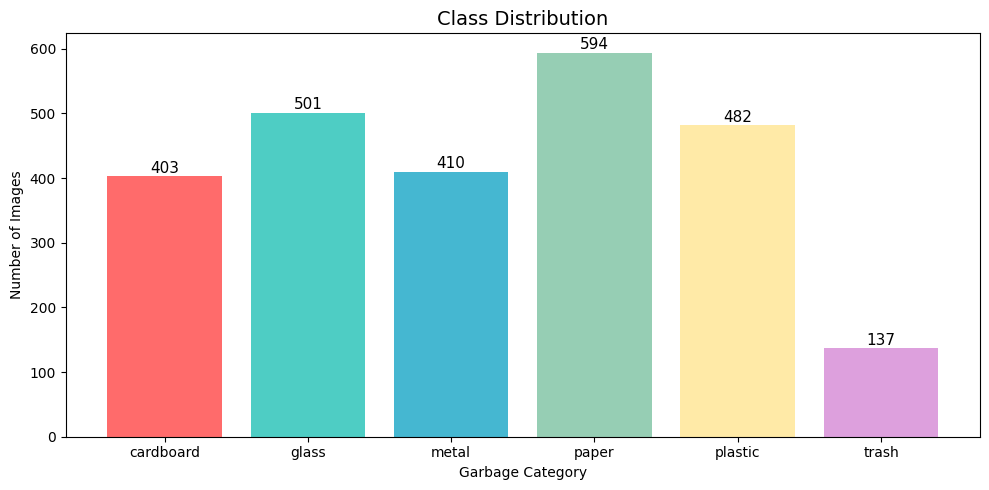

Plot saved to outputs/plots/


In [5]:
plt.figure(figsize=(10, 5))
bars = plt.bar(class_counts.keys(), class_counts.values(), 
               color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD'])
plt.title("Class Distribution", fontsize=14)
plt.xlabel("Garbage Category")
plt.ylabel("Number of Images")
for bar, count in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig("../outputs/plots/class_distribution.png", dpi=150)
plt.show()
print("Plot saved to outputs/plots/")

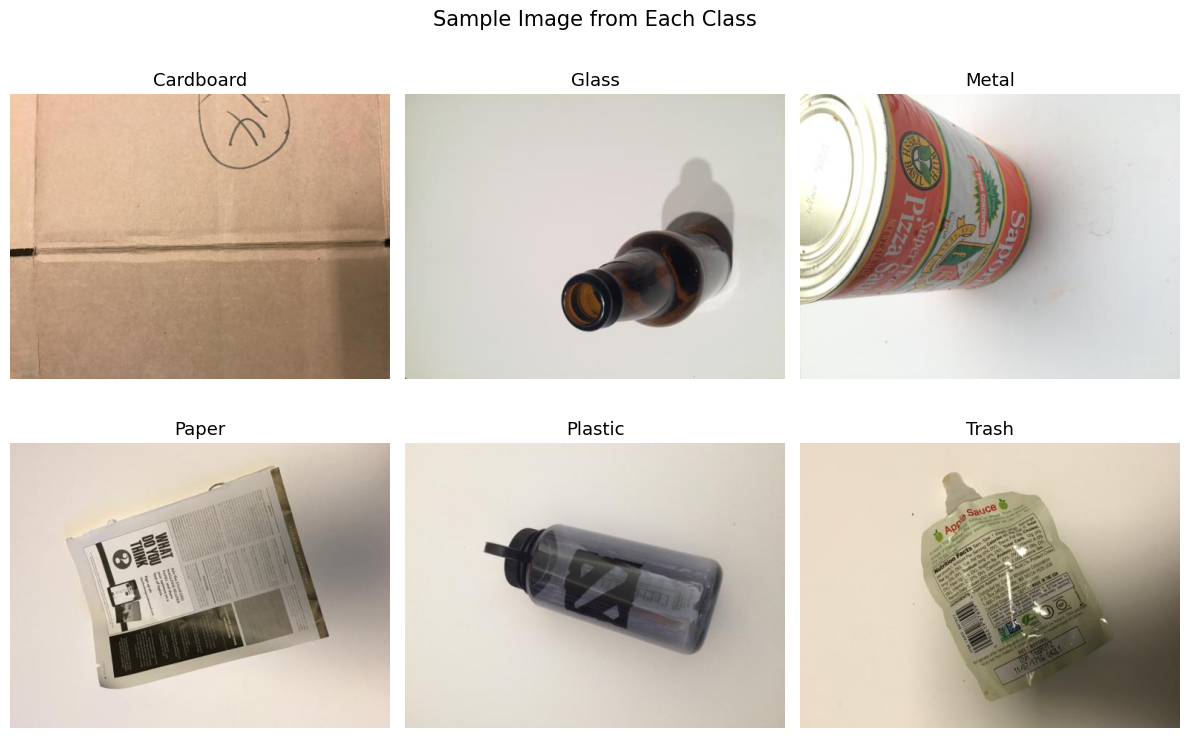

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, cls in enumerate(CLASSES):
    cls_path = os.path.join(DATA_DIR, cls)
    img_file = os.listdir(cls_path)[0]
    img = Image.open(os.path.join(cls_path, img_file))
    axes[idx].imshow(img)
    axes[idx].set_title(cls.capitalize(), fontsize=13)
    axes[idx].axis("off")

plt.suptitle("Sample Image from Each Class", fontsize=15)
plt.tight_layout()
plt.savefig("../outputs/plots/sample_images.png", dpi=150)
plt.show()

In [7]:
widths, heights = [], []
for cls in CLASSES:
    cls_path = os.path.join(DATA_DIR, cls)
    for img_file in os.listdir(cls_path)[:20]:  # sample 20 per class
        img = Image.open(os.path.join(cls_path, img_file))
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Width  — min: {min(widths)}, max: {max(widths)}, avg: {int(np.mean(widths))}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, avg: {int(np.mean(heights))}")
print(f"\nAll images will be resized to 224x224 for the model")

Width  — min: 512, max: 512, avg: 512
Height — min: 384, max: 384, avg: 384

All images will be resized to 224x224 for the model


## Section 3: Preprocessing & Data Augmentation

All images are resized to 224x224 to match ResNet18 input requirements.

**Training transforms:**
- Random horizontal flip
- Random rotation (±10°)
- Color jitter (brightness, contrast)
- Normalize with ImageNet mean and std

**Validation/Test transforms:**
- Resize and normalize only (no augmentation)

**Class imbalance:** The trash class has only 137 images (5.4%).
We handle this using a weighted loss function during training.

In [8]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("Transforms defined successfully")

Transforms defined successfully


In [9]:
# load full dataset with training transforms 
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)

# sizes: 70% train, 15% val, 15% test
total = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_set, val_set, test_set = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# apply val/test transforms separately
val_set.dataset.transform  = val_test_transforms
test_set.dataset.transform = val_test_transforms

print(f"Train size : {train_size}")
print(f"Val size   : {val_size}")
print(f"Test size  : {test_size}")
print(f"Classes    : {full_dataset.classes}")

Train size : 1768
Val size   : 379
Test size  : 380
Classes    : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [10]:
# computing class weights to handle trash imbalance
class_counts_list = [class_counts[c] for c in full_dataset.classes]
class_weights = 1.0 / torch.tensor(class_counts_list, dtype=torch.float)

# assign weight to each sample
sample_weights = [class_weights[label] for _, label in full_dataset.samples]
sample_weights = torch.tensor(sample_weights)

# only apply weighted sampler to training set
train_indices = train_set.indices
train_sample_weights = sample_weights[train_indices]

sampler = torch.utils.data.WeightedRandomSampler(
    weights=train_sample_weights,
    num_samples=len(train_sample_weights),
    replacement=True
)

print("Weighted sampler created to handle class imbalance")
print(f"Class weights: { {c: round(w.item(), 4) for c, w in zip(full_dataset.classes, class_weights)} }")

Weighted sampler created to handle class imbalance
Class weights: {'cardboard': 0.0025, 'glass': 0.002, 'metal': 0.0024, 'paper': 0.0017, 'plastic': 0.0021, 'trash': 0.0073}


In [11]:
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = len(full_dataset.classes)
print(f"\nDevice     : {DEVICE}")
print(f"Num classes: {NUM_CLASSES}")

Train batches : 56
Val batches   : 12
Test batches  : 12

Device     : cpu
Num classes: 6


## Section 4: Baseline CNN (From Scratch)

We first build a simple CNN as our baseline model.
Given the small dataset (~2,500 images), this model is expected to overfit —
which motivates data augmentation and transfer learning in later sections.

**Architecture:**
- 3 × (Conv2D → BatchNorm → ReLU → MaxPool)
- Dropout layers for regularization
- 2 Fully connected layers

In [12]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(BaselineCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model_cnn = BaselineCNN(num_classes=NUM_CLASSES).to(DEVICE)
print(model_cnn)
print(f"\nTotal parameters: {sum(p.numel() for p in model_cnn.parameters()):,}")

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropo

In [13]:
def train_model(model, train_loader, val_loader, epochs=15, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        scheduler.step()
        t_loss = train_loss / len(train_loader)
        v_loss = val_loss / len(val_loader)
        t_acc  = train_correct / len(train_loader.dataset)
        v_acc  = val_correct / len(val_loader.dataset)

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | "
              f"Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}")

    return history

print("Training function defined.")

Training function defined.


In [14]:
print("Training Baseline CNN — this may take 5–10 mins on CPU...")
history_cnn = train_model(model_cnn, train_loader, val_loader, epochs=15)

Training Baseline CNN — this may take 5–10 mins on CPU...
Epoch 01/15 | Train Loss: 5.0731 Acc: 0.3286 | Val Loss: 1.5581 Acc: 0.3536
Epoch 02/15 | Train Loss: 1.4161 Acc: 0.4180 | Val Loss: 1.3168 Acc: 0.4934
Epoch 03/15 | Train Loss: 1.3436 Acc: 0.4706 | Val Loss: 1.2831 Acc: 0.5066
Epoch 04/15 | Train Loss: 1.2408 Acc: 0.5068 | Val Loss: 1.2246 Acc: 0.5330
Epoch 05/15 | Train Loss: 1.1766 Acc: 0.5351 | Val Loss: 1.1320 Acc: 0.5594
Epoch 06/15 | Train Loss: 1.0912 Acc: 0.5667 | Val Loss: 1.1230 Acc: 0.5646
Epoch 07/15 | Train Loss: 1.0270 Acc: 0.5973 | Val Loss: 1.1244 Acc: 0.5963
Epoch 08/15 | Train Loss: 0.9716 Acc: 0.6295 | Val Loss: 1.1065 Acc: 0.6121
Epoch 09/15 | Train Loss: 0.9996 Acc: 0.6075 | Val Loss: 1.0391 Acc: 0.6280
Epoch 10/15 | Train Loss: 0.9328 Acc: 0.6312 | Val Loss: 1.0401 Acc: 0.6491
Epoch 11/15 | Train Loss: 0.8355 Acc: 0.6759 | Val Loss: 1.0441 Acc: 0.6438
Epoch 12/15 | Train Loss: 0.7803 Acc: 0.6867 | Val Loss: 0.9720 Acc: 0.6596
Epoch 13/15 | Train Loss: 0.79